# **NFL Players Tweet/Performance Analysis**

# Project Description

### Team Info

Cole Ballard
cballard7@angelo.edu

### Background

The integration of online data, such as NFL players' tweets and game statistics, provides a potentially useful approach to predicting performance and understanding game outcomes. By analyzing tweet sentiment, behavioral patterns, and public reactions, people can uncover correlations between players' mental states and on-field results, which can include factors influencing performance, such as focus, confidence, or distractions. Machine learning models enhance this analysis by identifying patterns and generating predictions based on both statistical and textual data with sentiment text-analysis.

### Problem

The performance of NFL players seems random or too complex to predict.

### Solution

Use NFL player tweets and data derived from those tweets to establish a relationship between performance and what NFL players are saying online.

### Applications

- Sports betting/fantasy football
- Understanding the relationship between mental state and performance in professional sports

## References

"Data-Driven Prediction of Athletes’ Performance Based on Their Social Media Presence": This research analyzed millions of tweets from NBA players to derive features reflecting mood, social media behavior, and sleep quality before games. The study found that the number of tweets a player is tagged in prior to a game significantly improves the accuracy of performance predictions. 
[Springer Nature Link](https://link.springer.com/chapter/10.1007/978-3-031-18840-4_15)

"Performance Prediction of Basketball Players Using Automated Personality Mining with Twitter Data": This study utilized Twitter data to mine personality traits of basketball players and predict their NBA performance. It concluded that certain personality traits, such as extraversion, agreeableness, and conscientiousness, correlate with basketball performance and can be used, alongside previous game statistics, to predict future performance. 
[Emerald Insight](https://www.emerald.com/insight/content/doi/10.1108/sbm-10-2021-0119/full/html)

"Prediction from Regional Angst – A Study of NFL Sentiment in Twitter Data": This research applied financial stock market techniques to sentiment gathered from social media to predict NFL game outcomes. The analysis revealed that sentiment-based wagers yielded higher average returns compared to an odds-only approach, indicating a significant relationship between social media sentiment and game performance. 
[Rob Schumaker](https://robschumaker.com/publications/DSS%20-%20Prediction%20from%20Regional%20Angst.pdf)

# Datasets

All of the data is **scraped**.

- https://www.pro-football-reference.com/friv/nfl-player-twitter.htm
    - A key-value-pair list of NFL player names and their twitter handle
- https://www.footballdb.com
    - A website that displays NFL player stats per-game
- https://x.com
    - A social media website that displays NFL player tweets

### Scraping Methods

**https://www.pro-football-reference.com/friv/nfl-player-twitter.htm**
- BeautifulSoup with HTML Parser to store table of NFL player names with a link to their twitter profile

**https://www.footballdb.com**
- BeautifulSoup with HTML Parser to store table of NFL player stats per-game
- Uses the NFL player names from the previous dataset to get stats for only the players that have a twitter profile

**https://x.com**
- Selenium Chrome Webdriver to store table of NFL player tweets
- Uses intersection of NFL players from first two datasets to get tweets for only the players that have stats and tweets

### Scraping Complications

- https://www.pro-football-reference.com/friv/nfl-player-twitter.htm
    - This dataset already includes a link to a webpage for the player which includes the desired data
        - Unfortunately, https://www.pro-football-reference.com limits basic HTTP requests, meaning traditional web scraping isn't an option
- https://x.com
    - Twitter has an API, but for free access, it's limited to 100 post reads per day, and higher tiers cost a minimum of over $200 a month
    - Twitter also has restrictions for how much content can be loaded, so only a few hundred posts can be extracted before a ~10 minute timeout occurs where no posts are loaded

### Purpose

The heart of the datasets and project is the NFL player-twitter handle mapping webpage. This data provides the base relationship between player performance and tweets. From this relationship, the other 2 datasets can be extracted and connected.

**Independent Variable:** NFL player tweets

**Dependent Variable:** NFL player performance

### Usage of Datasets

The relationship between performance and tweets will be established using different strategies. Then, analysis using different data representation methods will be used to create predictions with accuracy-based scoring to alleviate the perceived complexity and randomness of NFL player performance.

# Data Cleanup

## Imports

In [75]:
!pip install pandas numpy matplotlib seaborn scipy nltk textblob scikit-learn

import os
import warnings

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy.stats import skew

# Text analysis
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk
from textblob import TextBlob

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, classification_report, accuracy_score, confusion_matrix, mean_absolute_error, log_loss, make_scorer, silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score, StratifiedKFold
from sklearn.cluster import KMeans
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

# Configure plots to be inline
%matplotlib inline

### Notebook settings

In [2]:
warnings.filterwarnings("ignore")

model_accuracies = {}

## Loading Data

### Initializing dataframes

In [68]:
dataset_dir = '../dataset/'

player_handle_csv_file = f'{dataset_dir}player_handle.csv'
player_stat_csv_file = f'{dataset_dir}player_stat.csv'
player_tweet_csv_file = f'{dataset_dir}player_tweet.csv'

player_handle_df = pd.read_csv(player_handle_csv_file)
player_stat_df = pd.read_csv(player_stat_csv_file)
player_tweet_df = pd.read_csv(player_tweet_csv_file)

final_player_stat_csv_file = f'{dataset_dir}final_player_stat.csv'
final_player_tweet_csv_file = f'{dataset_dir}final_player_tweet.csv'

final_player_stat_tweet_csv_file = f'{dataset_dir}final_player_stat_tweet.csv'

### Checkpoints

In [69]:
# Check if the files exist before reading
if os.path.exists(final_player_tweet_csv_file):
    player_tweet_df = pd.read_csv(final_player_tweet_csv_file)

if os.path.exists(final_player_stat_csv_file):
    player_stat_df = pd.read_csv(final_player_stat_csv_file)

if os.path.exists(final_player_stat_tweet_csv_file):
    player_stat_tweet_df = pd.read_csv(final_player_stat_tweet_csv_file)

## Transformations

### Filter by Correct Years

In [5]:
# Convert the 'Date' column to datetime format
player_stat_df['Date'] = pd.to_datetime(player_stat_df['Date'], errors='coerce')

# Define the cutoff date to be the 2006 NFL season and onwards
cutoff_date = pd.Timestamp('2006-03-01')

# Filter the DataFrame
player_stat_df = player_stat_df[player_stat_df['Date'] > cutoff_date]

### Filter to only NFL games

In [6]:
# Filter the DataFrame
player_stat_df = player_stat_df[player_stat_df['Lg'] == 'NFL']

### Replace "--" values with 0

In [7]:
# Replace '--' with 0 in all columns except 'Date'
columns_to_replace = player_stat_df.columns.difference(['Date'])  # Exclude the 'Date' column
player_stat_df[columns_to_replace] = player_stat_df[columns_to_replace].replace('--', 0)

# Convert numeric columns to appropriate types after replacement
player_stat_df[columns_to_replace] = player_stat_df[columns_to_replace].apply(pd.to_numeric, errors='ignore')

### Convert Ratios (e.g. for field goal kicking) into floats

In [8]:
# Define a function to convert "X-Y" strings into X / Y
def convert_dash_to_float(value):
    if isinstance(value, str) and '-' in value:
        try:
            # Split the string into two parts and convert to integers
            x, y = map(int, value.split('-'))
            return x / y if y != 0 else np.nan  # Avoid division by zero
        except ValueError:
            return value  # Return the value unchanged if it's not valid
    return value

# Define a function to convert "X/Y" strings into X / Y
def convert_slash_to_float(value):
    if isinstance(value, str):
        if value == '/':  # Handle the special case where the value is just '/'
            return 0
        if '/' in value:
            try:
                # Split the string into two parts and convert to integers
                x, y = map(int, value.split('/'))
                return x / y if y != 0 else np.nan  # Avoid division by zero
            except ValueError:
                return value  # Return the value unchanged if it's not valid
    return value

# Apply the function to all columns except 'Date'
columns_to_convert = player_stat_df.columns.difference(['Date'])
player_stat_df[columns_to_convert] = player_stat_df[columns_to_convert].applymap(convert_dash_to_float)

slash_columns_to_convert = ['Kicking_PAT', 'Kicking_FG']
player_stat_df[slash_columns_to_convert] = player_stat_df[slash_columns_to_convert].applymap(convert_slash_to_float)

# Convert numeric columns to appropriate types after replacement
player_stat_df[slash_columns_to_convert] = player_stat_df[slash_columns_to_convert].apply(pd.to_numeric, errors='ignore')

### Remove trailing 't' from Lg stats

In [9]:
# Define the columns to clean (or target all non-numeric columns)
columns_to_clean = ['Punt Returns_Lg', 'Kickoff Returns_Lg', 'Interceptions_Lg', 'Receiving_Lg', 'Passing_Lg', 'Rushing_Lg']

# Remove trailing 't' characters from all values in the specified columns
player_stat_df[columns_to_clean] = player_stat_df[columns_to_clean].replace(r'(\d+)t$', r'\1', regex=True)

# Optionally, convert the cleaned columns to numeric where applicable
player_stat_df[columns_to_clean] = player_stat_df[columns_to_clean].apply(pd.to_numeric, errors='ignore')

### Ensure all non-numeric columns are expected

In [10]:
# Get non-numeric columns
non_numeric_columns = player_stat_df.select_dtypes(exclude='number')

# Print the names of the non-numeric columns
print("Non-numeric column names:", non_numeric_columns.columns.tolist())

Non-numeric column names: ['Player_Name', 'Res', 'Lg', 'Date', 'Opp', 'Team']


### Group Stats by Game

In [11]:
# Grouping by Player_Name, Res, Lg, Date, Opp, and Team
grouped_player_stat_df = player_stat_df.groupby(['Player_Name', 'Res', 'Lg', 'Date', 'Opp', 'Team'])

# Define a lambda function to calculate mean or keep NaN if all values are NaN
aggregate_function = lambda x: x.mean() if not x.isna().all() else float('nan')

# Apply the lambda function to all columns
player_stat_df = grouped_player_stat_df.agg({col: aggregate_function for col in player_stat_df.columns if col not in ['Player_Name', 'Res', 'Lg', 'Date', 'Opp', 'Team']}).reset_index()

### Save to csv

In [12]:
# Save the dataframe back to the CSV file
player_stat_df.to_csv(final_player_stat_csv_file, index=False)

## Create Player Performance Features

### Positive/negative feature split

In [13]:
positive_columns = [
    "Misc_PD",
    "Kickoffs_Lg",
    "Extra Points_Pct",
    "Passing_Att",
    "Kickoff Returns_Yds",
    "Receiving_Tar",
    "Punt Returns_Yds",
    "Field Goals_Lg",
    "Punt Returns_Lg",
    "Receiving_Rec",
    "Kickoff Returns_Num",
    "Touchdowns_P",
    "Punt Returns_Avg",
    "Rushing_TD",
    "Passing_Cmp",
    "Recoveries_Own",
    "Interceptions_TD",
    "Punts_Lg",
    "Touchdowns_IR",
    "Kickoffs_TB",
    "Kickoffs_TBLZ",
    "Punt Returns_Num",
    "Kickoff Returns_TD",
    "Field Goals_50+",
    "Punt Returns_FC",
    "Punts_Yds",
    "Field Goals_20-29",
    "Sacks_Sack",
    "Kickoff Returns_Lg",
    "Rushing_Gain",
    "Rushing_Att",
    "Kickoff Returns_FC",
    "Field Goals_FGA",
    "Passing_Pct",
    "Passing_YPA",
    "Touchdowns_R",
    "Tackles_Ast",
    "Kickoffs_Avg",
    "Misc_QBH",
    "Field Goals_FGM",
    "Rushing_Avg", 
    "Punts_50+", 
    "Punts_Avg", 
    "Passing_Yds", 
    "Field Goals_0-19", 
    "Kickoffs_Yds", 
    "Returns_Yds", 
    "Rushing_FD", 
    "Touchdowns_PR", 
    "Passing_Rate", 
    "Punts_In20", 
    "Extra Points_XPA", 
    "Returns_TD", 
    "Kicking_PAT", 
    "Field Goals_30-39", 
    "Field Goals_40-49", 
    "Receiving_20+", 
    "Pts", 
    "Receiving_FD", 
    "Receiving_TD", 
    "Rushing_Yds", 
    "Kickoffs_Num", 
    "Interceptions_Lg", 
    "Punts_Dwn", 
    "Field Goals_Pct", 
    "Recoveries_Tot", 
    "Passing_FD", 
    "Touchdowns_KR", 
    "Tackles_Solo", 
    "Receiving_Avg", 
    "Kickoff Returns_Avg", 
    "Touchdowns_Tot", 
    "Receiving_YAC", 
    "Extra Points_XPM", 
    "Receiving_Yds", 
    "Passing_TD%T%", 
    "Passing_TD", 
    "Kicking_FG", 
    "Receiving_Lg", 
    "Passing_Lg", 
    "Interceptions_Yds", 
    "Rushing_Lg", 
    "Touchdowns_FR", 
    "Kickoffs_In20", 
    "Rushing_10+", 
    "Misc_Conv",
    "Punts_Net",
    "Passing_20+",
    "Tackles_Tot",
    "Misc_Saf",
    "Punts_Num",
    "Punts_OB",
    "Punt Returns_TD",
    "Interceptions_Int", 
    "Fumbles_Forced",
    "Onside Kicks_OSR",
    "Onside Kicks_OSK",
    "Punts_FC", 
    "Sacks_YdsL",
    "Interceptions_Avg",
    "Misc_Pts",
]

negative_columns = [
    "Punts_Blk",
    "Passing_Sack",
    "Passing_Loss",
    "Opponent Returns_RYds",
    "Opp. Returns_TD",
    "Kickoffs_OB",
    "Opponent Returns_Ret",
    "Passing_Int",
    "Opponent Returns_TD",
    "Fumbles_Fum", 
    "Rushing_Loss", 
    "Opp. Returns_Ret", 
    "Fumbles_Lost", 
    "Punts_TB",  
    "Passing_Int%I%",
    "Opp. Returns_RYds",
    "Recoveries_Opp",
    "Kickoffs_Short"
]

### Player-relative performance

In [14]:
# Make a copy of the original DataFrame
player_relative_stat_df = player_stat_df.copy()

# Fill missing values with 0 for the specified columns
player_relative_stat_df[positive_columns + negative_columns] = player_relative_stat_df[positive_columns + negative_columns].fillna(0)

# Calculate per-row performance scores
player_relative_stat_df['Positive_Score'] = player_relative_stat_df[positive_columns].sum(axis=1)
player_relative_stat_df['Negative_Score'] = player_relative_stat_df[negative_columns].sum(axis=1)
player_relative_stat_df['Total_Score'] = player_relative_stat_df['Positive_Score'] - player_relative_stat_df['Negative_Score']

# For each player, find their min and max Total_Score
player_min = player_relative_stat_df.groupby('Player_Name')['Total_Score'].transform('min')
player_max = player_relative_stat_df.groupby('Player_Name')['Total_Score'].transform('max')

# Normalize each player's performance relative to their own historical range
player_relative_stat_df['Player_Relative_Performance'] = (player_relative_stat_df['Total_Score'] - player_min) / (player_max - player_min)

# If there are cases where a player has the same score for all games (max == min),
# you might end up dividing by zero. Handle that case by assigning a default value:
player_relative_stat_df['Player_Relative_Performance'] = player_relative_stat_df['Player_Relative_Performance'].fillna(0.5)

# Update the original DataFrame
player_stat_df = player_relative_stat_df.copy()

### Save to csv

In [15]:
# Save the dataframe back to the CSV file
player_stat_df.to_csv(final_player_stat_csv_file, index=False)

## Create Tweet Sentiment Features

### Positive, neutral, and negative classification (VADER rule-based lexicon)

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\coleb\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


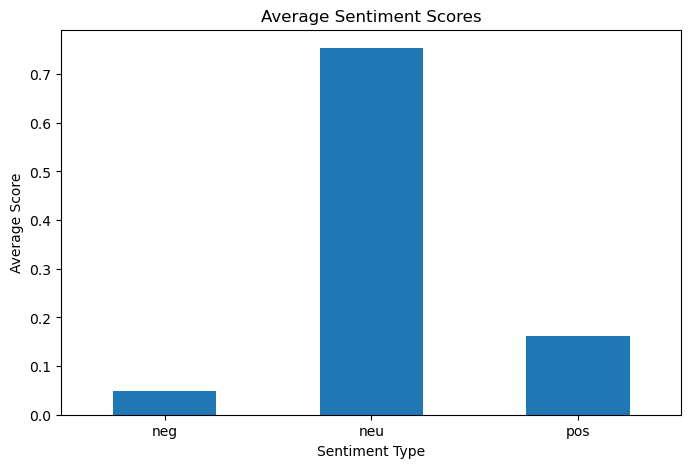

In [16]:
# Download necessary NLTK data
nltk.download('vader_lexicon')

# Initialize the sentiment analyzer
sia = SentimentIntensityAnalyzer()

# Replace non-string or NaN values in 'text' column with an empty string
player_tweet_df['text'] = player_tweet_df['text'].fillna('').astype(str)

# Add sentiment analysis columns
player_tweet_df[['neg', 'neu', 'pos', 'compound']] = player_tweet_df['text'].apply(
    lambda text: pd.Series(sia.polarity_scores(text))
)

# Group sentiment scores for visualization
sentiment_counts = player_tweet_df[['neg', 'neu', 'pos']].mean()

# Plot sentiment distribution
plt.figure(figsize=(8, 5))
sentiment_counts.plot(kind='bar', title='Average Sentiment Scores')
plt.xlabel('Sentiment Type')
plt.ylabel('Average Score')
plt.xticks(rotation=0)
plt.show()

### Polarity and subjectivity (TextBlob)

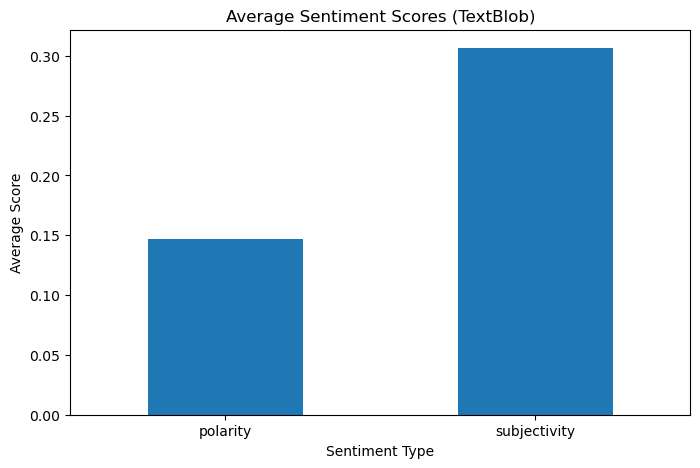

In [17]:
# Replace non-string or NaN values in 'text' column with an empty string
player_tweet_df['text'] = player_tweet_df['text'].fillna('').astype(str)

# Function to get sentiment scores from TextBlob
def get_textblob_sentiment(text):
    blob = TextBlob(text)
    polarity = blob.sentiment.polarity  # Polarity score ranges from -1 (negative) to 1 (positive)
    subjectivity = blob.sentiment.subjectivity  # Subjectivity score ranges from 0 (objective) to 1 (subjective)
    return pd.Series([polarity, subjectivity])

# Add sentiment analysis columns
player_tweet_df[['polarity', 'subjectivity']] = player_tweet_df['text'].apply(get_textblob_sentiment)

# Group sentiment polarity for visualization
average_sentiment = player_tweet_df[['polarity', 'subjectivity']].mean()

# Plot sentiment distribution
plt.figure(figsize=(8, 5))
average_sentiment.plot(kind='bar', title='Average Sentiment Scores (TextBlob)')
plt.xlabel('Sentiment Type')
plt.ylabel('Average Score')
plt.xticks(rotation=0)
plt.show()


### Save to csv

In [18]:
# Save the dataframe back to the CSV file
player_tweet_df.to_csv(final_player_tweet_csv_file, index=False)

## Combining Datasets

### Creating relationship between player performance and tweets

In [19]:
# Convert date columns to datetime
player_stat_df['Date'] = pd.to_datetime(player_stat_df['Date'])
player_tweet_df['date'] = pd.to_datetime(player_tweet_df['date'])

# Merge player_stat with player_handle to get twitter_username
# Assuming "Player_Name" in player_stat matches "player_name" in player_handle
merged_stats = pd.merge(player_stat_df, player_handle_df, how='inner', 
                        left_on='Player_Name', right_on='player_name')

# Merge tweets with merged_stats on twitter_username
# We'll do an inner merge on twitter_username
merged = pd.merge(merged_stats, player_tweet_df, how='inner', 
                  left_on='twitter_profile', right_on='player_handle')

# Ensure both columns are timezone-naive
merged['Date'] = merged['Date'].dt.tz_localize(None)
merged['date'] = merged['date'].dt.tz_localize(None)

# Now filter so that only tweets from the previous 30 days are included
# Condition: Game_Date - Tweet_Date >= 0 and <= 30 days
merged['Days_Before_Game'] = (merged['Date'] - merged['date']).dt.days

# Keep only rows where Days_Before_Game is between 0 and 30 (inclusive)
filtered = merged[(merged['Days_Before_Game'] >= 0) & (merged['Days_Before_Game'] <= 30)]

# Select the columns you want to keep.
# The final table should include columns from player_stat, plus is_repost,neg,neu,pos,compound,polarity,subjectivity from tweets
final_columns = ['Player_Name', 'Date', 'Player_Relative_Performance'] + [
    'is_repost','neg','neu','pos','compound','polarity','subjectivity','Days_Before_Game'
]
# Ensure these columns exist in filtered
final_columns = [col for col in final_columns if col in filtered.columns]

player_stat_tweet_df = filtered[final_columns].copy()

# final now contains the joined table grouped by each player game with associated tweets
# If you want to group or sort the final result, you can do so here.
# For example, sorting by Player_Name, Date, Days_Before_Game:
player_stat_tweet_df.sort_values(by=['Player_Name', 'Date', 'Days_Before_Game'], inplace=True)

# Write out or use final as needed
player_stat_tweet_df.to_csv(final_player_stat_tweet_csv_file, index=False)

# Data Exploration

## Feature Identification

In [20]:
# Convert the Date column to datetime
player_stat_tweet_df['Date'] = pd.to_datetime(player_stat_tweet_df['Date'])

# Separate numerical and categorical features
# Note: After conversion, 'Date' is no longer object type. Let's assume we still consider it separately.
numerical_features = player_stat_tweet_df.select_dtypes(include=["float64", "int64"]).columns.tolist()
boolean_features = player_stat_tweet_df.select_dtypes(include=["bool"]).columns.tolist()

# For categorical, let's consider strings and possibly datetime as a separate case:
object_like_features = player_stat_tweet_df.select_dtypes(include=["object"]).columns.tolist()
datetime_features = player_stat_tweet_df.select_dtypes(include=["datetime"]).columns.tolist()

# Get ranges for numerical features
numerical_ranges = {col: (player_stat_tweet_df[col].min(), player_stat_tweet_df[col].max()) for col in numerical_features}

# For datetime features, show a date range
datetime_ranges = {col: (player_stat_tweet_df[col].min(), player_stat_tweet_df[col].max()) for col in datetime_features}

# For object/boolean features (categorical), show unique values
categorical_values = {col: player_stat_tweet_df[col].unique().tolist() for col in object_like_features + boolean_features}

# Display the results
print("Numerical Features and Ranges:")
for col, range_ in numerical_ranges.items():
    print(f"{col}: Min = {range_[0]}, Max = {range_[1]}")

print("\nDatetime Features and Ranges:")
for col, range_ in datetime_ranges.items():
    print(f"{col}: From {range_[0].date()} to {range_[1].date()}")

print("\nCategorical Features and Values:")
for col, values in categorical_values.items():
    if len(values) > 2:
        print(f"{col} Count: {len(values)}")
    else:
        print(f"{col}: {values}")

Numerical Features and Ranges:
Player_Relative_Performance: Min = 0.0, Max = 1.0
neg: Min = 0.0, Max = 1.0
neu: Min = 0.0, Max = 1.0
pos: Min = 0.0, Max = 1.0
compound: Min = -0.9756, Max = 0.9892
polarity: Min = -1.0, Max = 1.0
subjectivity: Min = 0.0, Max = 1.0
Days_Before_Game: Min = 0.0, Max = 30.0

Datetime Features and Ranges:
Date: From 2011-09-11 to 2024-12-01

Categorical Features and Values:
Player_Name Count: 67
is_repost: [True, False]


## Seaborn single feature plots

### Histogram of subjectivity

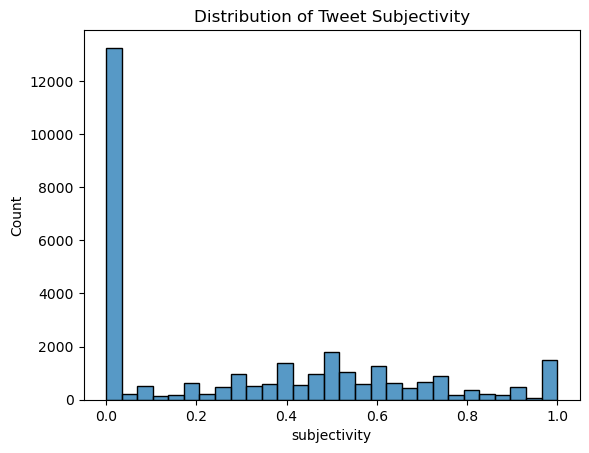

In [21]:
sns.histplot(player_tweet_df, x='subjectivity')
plt.title('Distribution of Tweet Subjectivity')
plt.show()

Explanation

There seems to be a slight bell curve besides the extremes. This indicates the existence of outliers that could potentially be removed for more accurate modeling.

### Kernel Density Estimate (KDE) Plot of Player_Relative_Performance

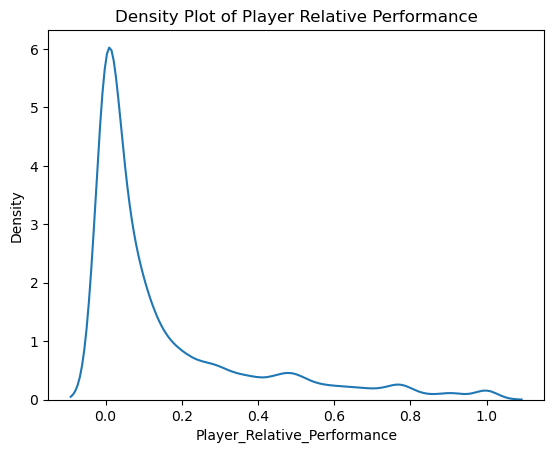

In [22]:
sns.kdeplot(player_stat_df['Player_Relative_Performance'].dropna())
plt.title('Density Plot of Player Relative Performance')
plt.show()

Explanation

Players seem to generally perform signficantly worse than their peak. Also might indicate outliers where players didn't play.

### Count Plot of Days_Before_Game

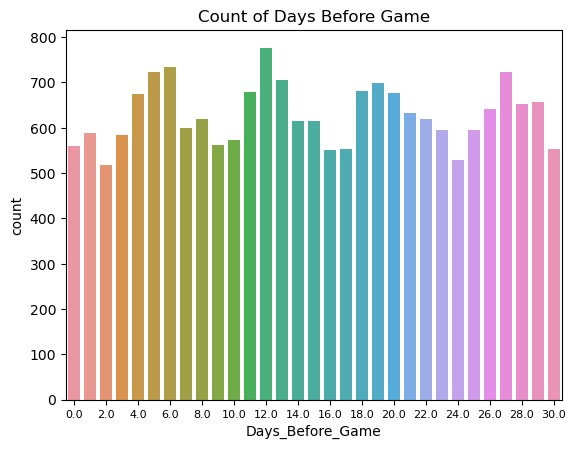

In [23]:
sns.countplot(data=player_stat_tweet_df, x='Days_Before_Game')
plt.title('Count of Days Before Game')

# Get the current tick locations and labels
ticks = plt.xticks()[0]  # Get the positions of the ticks
labels = plt.xticks()[1]  # Get the labels of the ticks

# Set ticks and labels, skipping every other tick
plt.xticks(ticks=ticks[::2], labels=[label.get_text() for label in labels[::2]], fontsize=8)

plt.show()

Explanation

Players seem to tweet most often the day after their games (days = multiples of 7 - 1). 

Although there might exist a relationship between further occuring tweets, we might consider tranforming the feature to be exponential or logarithmic across its range so that the further a tweet occured from a game, it becomes exponentially less meaningful or logarithmically less meaningful.

### Box Plot of compound

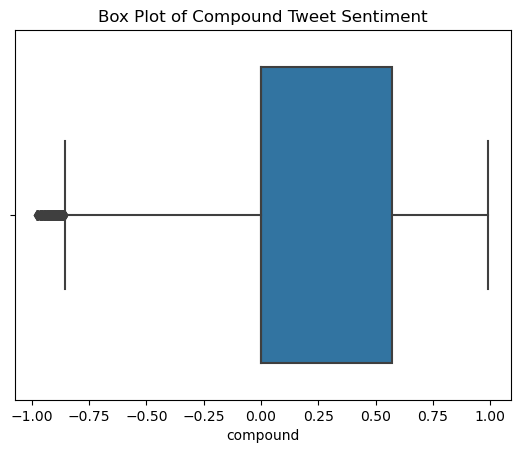

In [24]:
sns.boxplot(data=player_tweet_df, x='compound')
plt.title('Box Plot of Compound Tweet Sentiment')
plt.show()

#### Explanation

The vast majority of tweets are mostly positive (indicated by the range of 0.0-0.6).

### Violin Plot of Date

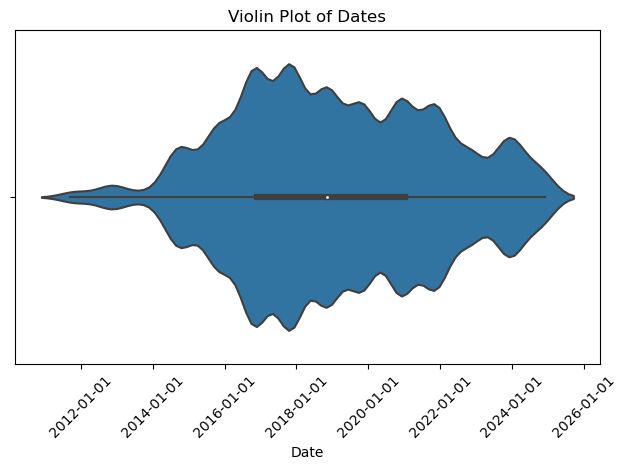

In [25]:
# Convert the Date column to numeric values
player_stat_tweet_df['Date_numeric'] = mdates.date2num(player_stat_tweet_df['Date'])

# Create a violin plot
sns.violinplot(data=player_stat_tweet_df, x='Date_numeric')
plt.title('Violin Plot of Dates')
plt.xlabel('Date')

# Format the x-axis to show dates
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Explanation

Most tweet-game matches for our dataset occurred from 2016-2022. 

Date's might be a signficant factor for how social media has evolved in the NFL and how players attitudes towards it have changed. Including date (as numeric) might be useful for modeling.

## Two feature plots in seaborn

### Scatter Plot of VADER vs TextBlob Tweet Sentiment with Subjectivity

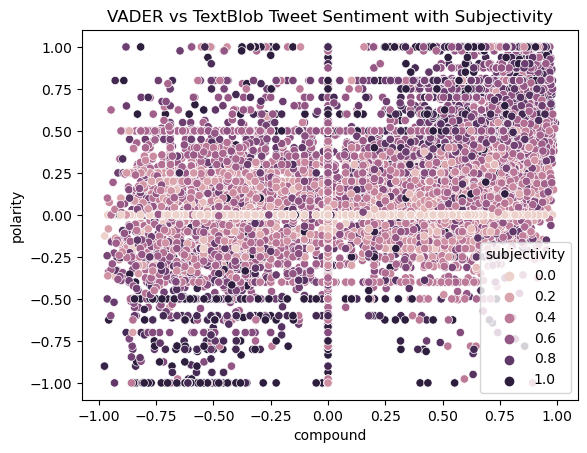

In [26]:
# Explanation: This scatter plot visualizes the relationship between passing yards and rushing yards, with points colored by game result. It helps identify any correlation between the two variables and how they relate to winning or losing games.
sns.scatterplot(data=player_tweet_df, x='compound', y='polarity', hue='subjectivity')
plt.title('VADER vs TextBlob Tweet Sentiment with Subjectivity')
plt.show()

#### Explanation

VADER Compound and TextBlob Polarity are meant to provide analysis on similiar measurements. If they matched exactly, they would line up perfectly in a linear fashion (graph that looks like y = x). Their differences are most likely signficant and using both in conjunction with each other is probably necessary.

It can also be seen that outliers (negative correlation or y = -x) tend to be highly subjective.

### Swarm Plot of Player Relative Performance by Polarity for Very Recent Tweets

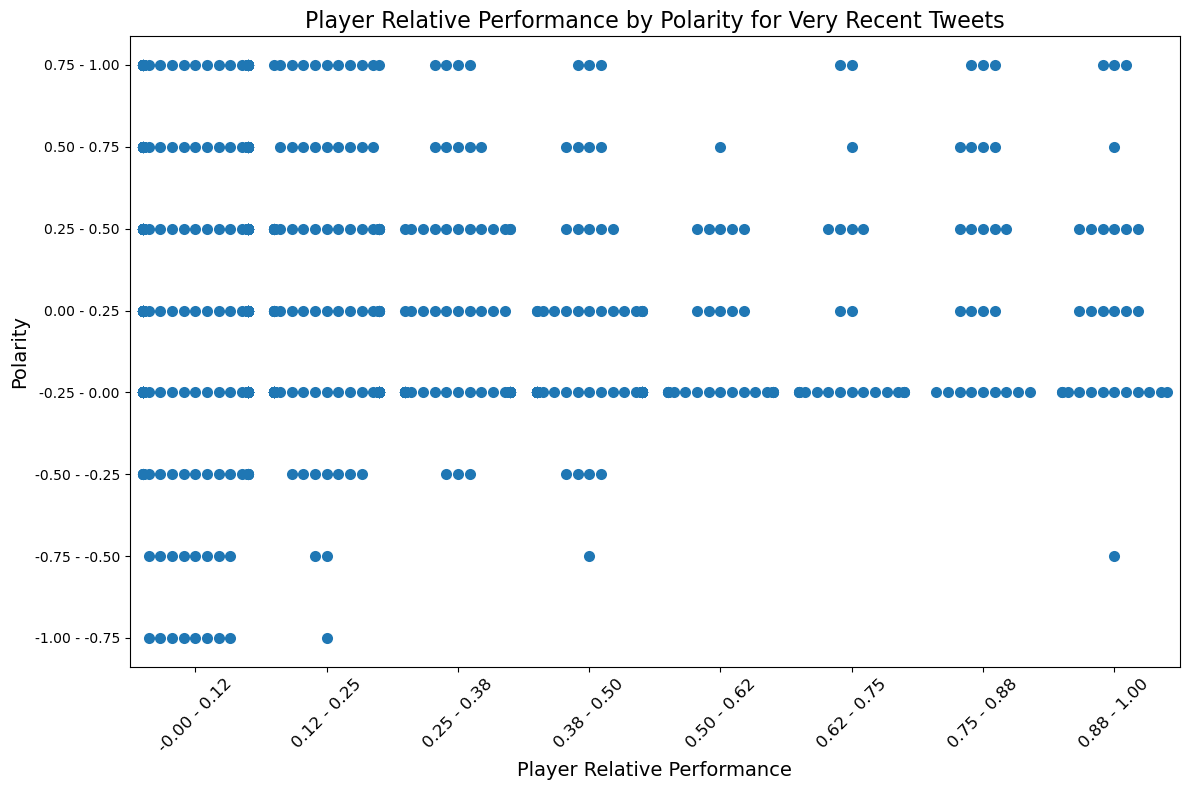

In [27]:
# Filter the DataFrame
filtered_df = player_stat_tweet_df[
    (player_stat_tweet_df['Days_Before_Game'] <= 1)
]

# Bin the 'Player_Relative_Performance' into 8 bins
performance_bins = pd.cut(filtered_df['Player_Relative_Performance'], bins=8)
polarity_bins = pd.cut(filtered_df['polarity'], bins=8)

# Extract categories for creating labels
performance_bin_labels = [f"{bin.left:.2f} - {bin.right:.2f}" for bin in performance_bins.cat.categories]
polarity_bin_labels = [f"{bin.left:.2f} - {bin.right:.2f}" for bin in polarity_bins.cat.categories]

# Map bins back to their labeled categories for plotting
filtered_df['Performance_Bins'] = pd.cut(
    filtered_df['Player_Relative_Performance'], 
    bins=8,
    labels=performance_bin_labels
)
filtered_df['Polarity_Bins'] = pd.cut(
    filtered_df['polarity'], 
    bins=8,
    labels=polarity_bin_labels
)

# Create the swarm plot with sorted bins
plt.figure(figsize=(12, 8))
sns.swarmplot(
    x='Performance_Bins',
    y='Polarity_Bins',
    data=filtered_df,
    order=performance_bin_labels,  # Ensure sorted order for x-axis
    hue_order=None,  # Ensure sorted order for y-axis
    size=8
)

# Manually set the y-axis order to ascending
plt.gca().invert_yaxis()

# Customize the plot
plt.title('Player Relative Performance by Polarity for Very Recent Tweets', fontsize=16)
plt.xlabel('Player Relative Performance', fontsize=14)
plt.ylabel('Polarity', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.tight_layout()

# Show the plot
plt.show()


#### Explanation

For very recent tweets (0-1 days before) associated with high performance games, players usually don't tweet negatively.

### Strip Plot of Player Relative Performance associated with Negative Tweets on Different Days

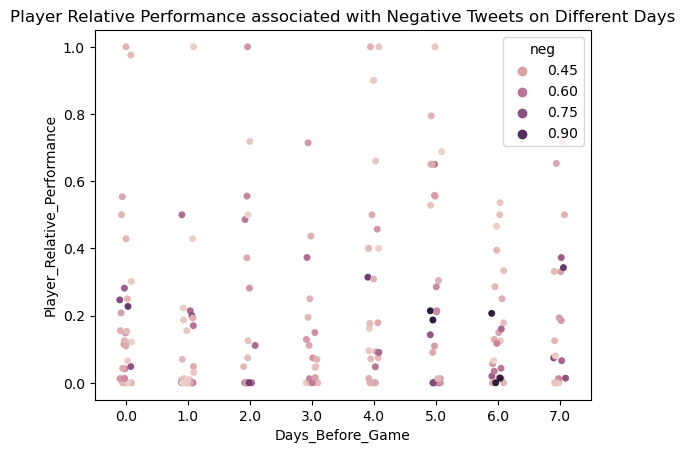

In [28]:
# Filter the DataFrame
filtered_df = player_stat_tweet_df[
    (player_stat_tweet_df['Days_Before_Game'] <= 7) &
    (player_stat_tweet_df['neg'] >= 0.3)
]

sns.stripplot(data=filtered_df, x='Days_Before_Game', y='Player_Relative_Performance', jitter=True, hue='neg')
plt.title('Player Relative Performance associated with Negative Tweets on Different Days')
plt.show()

#### Explanation

A few insights can be seen from this visualization:
- Players who tweet negatively 5 days before the game tend to have better performances
- All of the very negative tweets (neg = 0.9) occur 5 or 6 days before a game
    - These might be associated with the aftermath of the previous game (possibly trash talking after beating an opponent) and might indicate that a player or team is doing well for the entire season
- There aren't many negative tweets 1-3 days before a game, and the players that do tweet negatively during this period don't perform as well

## Exploratory data analysis

### Understand the Data

In [29]:
# Size of the Dataset:
print(player_stat_tweet_df.shape)

(19485, 12)


### Identify Relationships Between Features

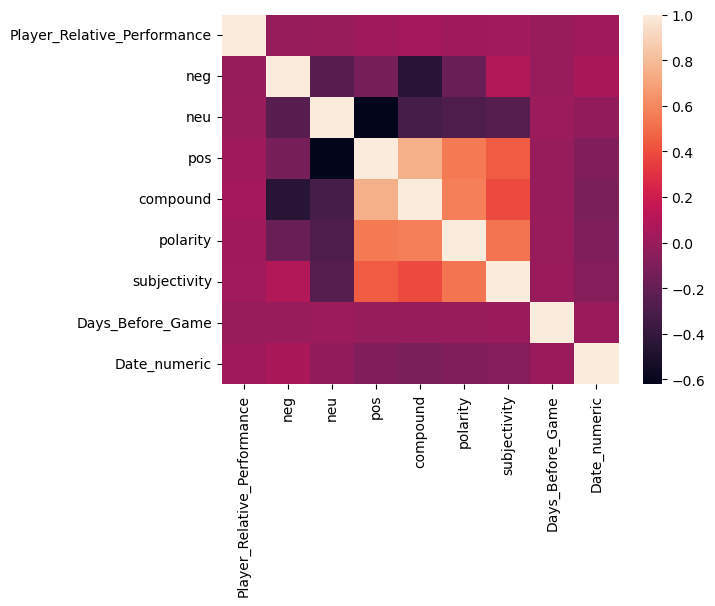

In [30]:
numerical_cols = player_stat_tweet_df.select_dtypes(include=['float64', 'int64']).columns
correlation = player_stat_tweet_df[numerical_cols].corr()
sns.heatmap(correlation)
plt.show()

#### Explanation

Player Relative Performance doesn't correlate directly with any of the tweet analysis metrics.

### Describe the Shape of Data

In [31]:
# Identify numeric columns
numeric_columns = ['Player_Relative_Performance', 'neg', 'neu', 'pos', 'compound', 'polarity', 'subjectivity', 'Days_Before_Game']

# Calculate skewness
skewness_values = player_stat_tweet_df[numeric_columns].apply(skew)

# Print skewness values
print("Skewness of Numeric Columns:")
print(skewness_values)

Skewness of Numeric Columns:
Player_Relative_Performance    1.641067
neg                            4.039496
neu                           -1.095997
pos                            1.202776
compound                       0.004629
polarity                       0.747629
subjectivity                   0.678320
Days_Before_Game               0.010476
dtype: float64


#### Explanation

**Player_Relative_Performance (Skewness = 1.641067)**
- Positive Skew: The distribution is skewed to the right.
- Interpretation: Most performances are below the player's relative peak, with a few high values pulling the mean upward. This might indicate that players typically perform closer to their average or worst performance relative to their best.

**neg (Skewness = 4.039496)**
- Strong Positive Skew: A highly right-skewed distribution.
- Interpretation: Most tweets have low negative sentiment scores, but a few tweets have very high negative sentiment, pulling the distribution's tail to the right. This could indicate that strongly negative tweets are rare.

**neu (Skewness = -1.095997)**
- Negative Skew: The distribution is skewed to the left.
- Interpretation: Many tweets have high neutral sentiment scores, but a few tweets have significantly lower neutral scores, pulling the tail to the left. This indicates that highly neutral tweets dominate the data, with a few exceptions.

**pos (Skewness = 1.202776)**
- Positive Skew: The distribution is skewed to the right.
- Interpretation: Many tweets have low positive sentiment, but a few tweets with very high positive sentiment create a long right tail. Strongly positive tweets are less common.

**compound (Skewness = 0.004629)**
- Nearly Symmetric: Skewness close to 0 indicates a balanced distribution.
- Interpretation: The overall sentiment of tweets (accounting for positive, neutral, and negative components) is evenly distributed, with no significant bias toward extreme positive or negative sentiment.

**polarity (Skewness = 0.747629)**
- Moderate Positive Skew: The distribution is slightly skewed to the right.
- Interpretation: Tweets tend to have a slight bias toward neutral or slightly positive polarity, with a few tweets having strong positive polarity.

**subjectivity (Skewness = 0.678320)**
- Moderate Positive Skew: The distribution is slightly skewed to the right.
- Interpretation: Most tweets are more objective, but a few tweets are highly subjective, pulling the distribution's tail to the right. This might indicate that objective statements are more common in the dataset.

**Days_Before_Game (Skewness = 0.010476)**
- Nearly Symmetric: Skewness close to 0.
- Interpretation: The days before the game are distributed almost symmetrically, suggesting an even spread of tweets across this variable.

### Detect Outliers and Missing Data

**Missing Data:**

No data is missing, as all the relevant fields have been filtered to include only the correct data.

**Outliers:**

As previously discussed, the primary outliers and discrepancies within the data include: 
- Player Relative Performances of 0
- VADER compound vs TextBlob polarity
- Highly objective tweets
- Tweets associated with different games
- (Maybe) reposts

## Dataset Summary

### Shape of the Dataset

In [32]:
print(player_stat_tweet_df.shape)

(19485, 12)


### Information About the Dataset

In [33]:
player_stat_tweet_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19485 entries, 5242 to 3897923
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Player_Name                  19485 non-null  object        
 1   Date                         19485 non-null  datetime64[ns]
 2   Player_Relative_Performance  19485 non-null  float64       
 3   is_repost                    19485 non-null  bool          
 4   neg                          19485 non-null  float64       
 5   neu                          19485 non-null  float64       
 6   pos                          19485 non-null  float64       
 7   compound                     19485 non-null  float64       
 8   polarity                     19485 non-null  float64       
 9   subjectivity                 19485 non-null  float64       
 10  Days_Before_Game             19485 non-null  float64       
 11  Date_numeric                 19485 non-nu

### Statistical Summary

In [34]:
player_stat_tweet_df.describe(include='all')

,Player_Name,Date,Player_Relative_Performance,is_repost,neg,neu,pos,compound,polarity,subjectivity,Days_Before_Game,Date_numeric
count,19485,19485,19485.000000,19485,19485.000000,19485.000000,19485.000000,19485.000000,19485.000000,19485.000000,19485.000000,19485.000000
unique,67,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Mike Adams,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1295,NaN,NaN,10093,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,2019-02-06 18:16:07.759815424,0.177707,NaN,0.038195,0.749324,0.171987,0.241411,0.161205,0.292315,15.057737,17933.761201
min,NaN,2011-09-11 00:00:00,0.000000,NaN,0.000000,0.000000,0.000000,-0.975600,-1.000000,0.000000,0.000000,15228.000000
25%,NaN,2016-11-27 00:00:00,0.000000,NaN,0.000000,0.597000,0.000000,0.000000,0.000000,0.000000,7.000000,17132.000000
50%,NaN,2018-11-11 00:00:00,0.074074,NaN,0.000000,0.803000,0.074000,0.000000,0.000000,0.200000,15.000000,17846.000000
75%,NaN,2021-01-03 00:00:00,0.255243,NaN,0.000000,1.000000,0.300000,0.585900,0.312500,0.543750,23.000000,18630.000000
max,NaN,2024-12-01 00:00:00,1.000000,NaN,1.000000,1.000000,1.000000,0.989200,1.000000,1.000000,30.000000,20058.000000


## Visualization Methods

### Histograms of Numerical Features

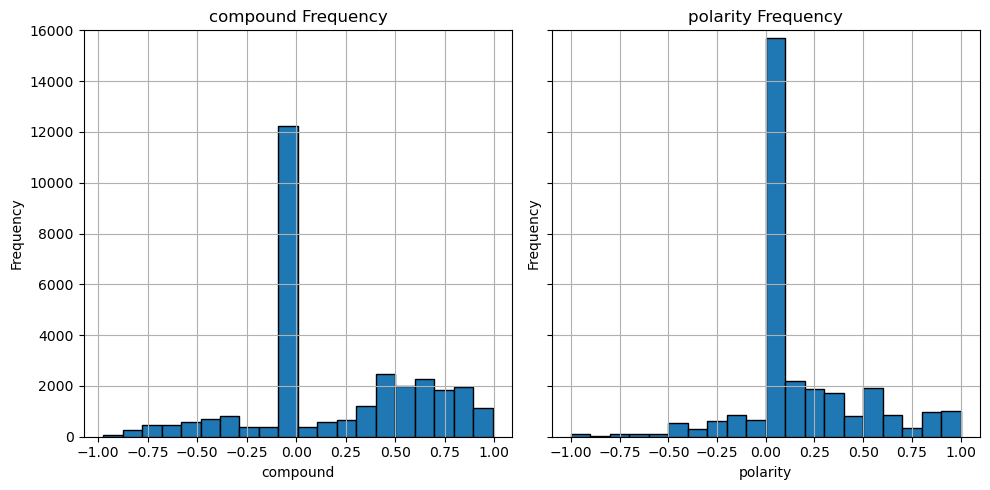

In [35]:
# Select numerical features for histograms
selected_features = ['compound', 'polarity']

# Plot histograms with consistent y-axis
fig, axes = plt.subplots(1, len(selected_features), figsize=(10, 5), sharey=True)

for ax, feature in zip(axes, selected_features):
    player_tweet_df[feature].hist(ax=ax, bins=20, edgecolor='black')
    ax.set_title(f'{feature} Frequency')
    ax.set_ylim(0, 16000)
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

#### Explanation

Polarity seems to perceive the tweets as more neutral, while compound seems to perceive the tweets as more positive.

### Box Plots of Numerical Features

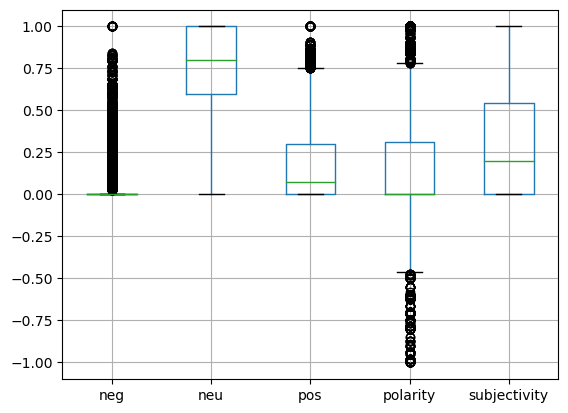

In [36]:
# Explanation: Box plots help visualize the spread and identify outliers in the data.
player_stat_tweet_df[['neg', 'neu', 'pos', 'polarity', 'subjectivity']].boxplot()
plt.show()

#### Explanation

**neg:**
- The vast majority of values are very close to 0
- There are fewer and fewer outliers as neg increases

**neu:**
- The range includes the entire 0-1 scale
- Most of the data is around 0.8 and everything else is close to that

**pos:**
- The majority of values are close to 0
- Most tweets are slightly positive

**polarity:**
- Most tweets are slightly positive but the median is 0
- There are outliers throughout the scale (probably represents a bell curve)

**subjectivity:**
- Most tweets are fairly subjective

### Scatter Matrix of Numerical Features

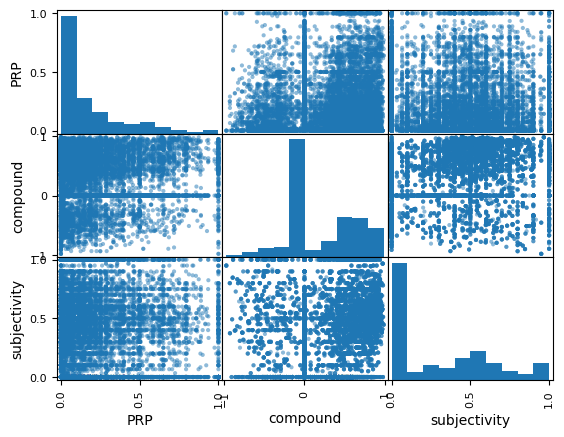

In [37]:
# Explanation: The scatter matrix displays pairwise relationships between numerical features, useful for detecting correlations.
shortened_df = player_stat_tweet_df.rename(columns={'Player_Relative_Performance': 'PRP'})
pd.plotting.scatter_matrix(shortened_df[['PRP', 'compound', 'subjectivity']])
plt.show()

#### Explanation

There seems to be general grouping in the graphs that show correlation with Relative Player Performance, which could be useful for Non-Parametric models like KNN.

## Outlier Detection and Cleaning

All the data has been cleaned and transformed to include only necessary features in the previous sections.

The outliers discussed shouldn't be removed, because they will offer different parameters and perspectives for models and could prove useful.

### Creating relationship between player performance and tweets

In [38]:
# Convert date columns to datetime
player_stat_df['Date'] = pd.to_datetime(player_stat_df['Date'])
player_tweet_df['date'] = pd.to_datetime(player_tweet_df['date'])

# Merge player_stat with player_handle to get twitter_username
# Assuming "Player_Name" in player_stat matches "player_name" in player_handle
merged_stats = pd.merge(player_stat_df, player_handle_df, how='inner', 
                        left_on='Player_Name', right_on='player_name')

# Merge tweets with merged_stats on twitter_username
# We'll do an inner merge on twitter_username
merged = pd.merge(merged_stats, player_tweet_df, how='inner', 
                  left_on='twitter_profile', right_on='player_handle')

# Ensure both columns are timezone-naive
merged['Date'] = merged['Date'].dt.tz_localize(None)
merged['date'] = merged['date'].dt.tz_localize(None)

# Now filter so that only tweets from the previous 30 days are included
# Condition: Game_Date - Tweet_Date >= 0 and <= 30 days
merged['Days_Before_Game'] = (merged['Date'] - merged['date']).dt.days

# Keep only rows where Days_Before_Game is between 0 and 30 (inclusive)
filtered = merged[(merged['Days_Before_Game'] >= 0) & (merged['Days_Before_Game'] <= 30)]

# Select the columns you want to keep.
# The final table should include columns from player_stat, plus is_repost,neg,neu,pos,compound,polarity,subjectivity from tweets
final_columns = ['Player_Name', 'Date', 'Player_Relative_Performance'] + [
    'is_repost','neg','neu','pos','compound','polarity','subjectivity','Days_Before_Game'
]
# Ensure these columns exist in filtered
final_columns = [col for col in final_columns if col in filtered.columns]

player_stat_tweet_df = filtered[final_columns].copy()

# final now contains the joined table grouped by each player game with associated tweets
# If you want to group or sort the final result, you can do so here.
# For example, sorting by Player_Name, Date, Days_Before_Game:
player_stat_tweet_df.sort_values(by=['Player_Name', 'Date', 'Days_Before_Game'], inplace=True)

# Write out or use final as needed
player_stat_tweet_df.to_csv(final_player_stat_tweet_csv_file, index=False)

### Save to csv

In [39]:
# Save the dataframe back to the CSV file
player_stat_tweet_df.to_csv(final_player_stat_tweet_csv_file, index=False)

# Regression

## 2 Attribute Linear Regression

### Creating and training model

In [40]:
# Selecting the attributes
lin_reg_2_X = player_stat_tweet_df[["compound", "Days_Before_Game"]]
lin_reg_2_y = player_stat_tweet_df["Player_Relative_Performance"]

# Creating and training the linear regression model
model = LinearRegression()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(lin_reg_2_X)
model.fit(X_scaled, lin_reg_2_y)

# Making predictions
y_pred = model.predict(lin_reg_2_X)

### Visualizing and measuring performance

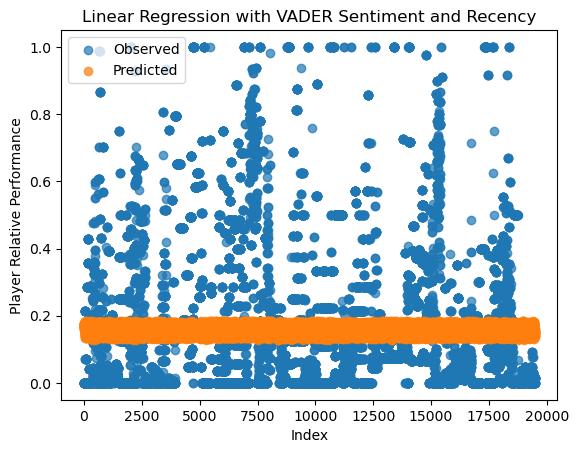

In [41]:
# Measuring performance
mse = mean_squared_error(lin_reg_2_y, y_pred)
r2 = r2_score(lin_reg_2_y, y_pred)
mae = mean_absolute_error(lin_reg_2_y, y_pred)

# Plotting observed vs predicted values
plt.scatter(range(len(lin_reg_2_y)), lin_reg_2_y, label="Observed", alpha=0.7)
plt.scatter(range(len(y_pred)), y_pred, label="Predicted", alpha=0.7)
plt.title("Linear Regression with VADER Sentiment and Recency")
plt.xlabel("Index")
plt.ylabel("Player Relative Performance")
plt.legend()
plt.show()

model_accuracies['2_linear_reg'] = {
    'mean_squared_error': mse,
    'r2_score': r2,
    'mean_absolute_error': mae
}

### Model Results

Using the initial dataset to predict Player Relative Performance led to several findings:
- The model is severely underfit
    - This is probably because the current data has virtually no correlation, so the model simply uses the mean of the dataset to make predictions
- Linear regression will most likely not be good for this problem
    - A more complex model will be needed to understand deeper relationships

## Accuracy-based Data Transformations

### Creating interval variable to filter data

In [42]:
absolute_range_var = 0.05

### Creating new df

In [43]:
transformed_player_stat_tweet_df = player_stat_tweet_df.copy()

### Combining compound and polarity features using mean

In [44]:
transformed_player_stat_tweet_df['compound_polarity_avg'] = (transformed_player_stat_tweet_df['compound'] + transformed_player_stat_tweet_df['polarity']) / 2.0

### Remove Player Relative Performances < 0.05

In [45]:
transformed_player_stat_tweet_df = transformed_player_stat_tweet_df[(transformed_player_stat_tweet_df['Player_Relative_Performance'] >= absolute_range_var)]

### Remove highly objective tweets

In [46]:
transformed_player_stat_tweet_df = transformed_player_stat_tweet_df[(transformed_player_stat_tweet_df['subjectivity'] >= absolute_range_var)]

### Remove very neutral tweets

In [47]:
# Not using because accuracy is higher when included
transformed_player_stat_tweet_df = transformed_player_stat_tweet_df[(transformed_player_stat_tweet_df['compound_polarity_avg'] >= absolute_range_var) | (transformed_player_stat_tweet_df['compound_polarity_avg'] <= -absolute_range_var)]

### Analysis of transformed df

In [48]:
transformed_player_stat_tweet_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5856 entries, 7590 to 3867219
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Player_Name                  5856 non-null   object        
 1   Date                         5856 non-null   datetime64[ns]
 2   Player_Relative_Performance  5856 non-null   float64       
 3   is_repost                    5856 non-null   bool          
 4   neg                          5856 non-null   float64       
 5   neu                          5856 non-null   float64       
 6   pos                          5856 non-null   float64       
 7   compound                     5856 non-null   float64       
 8   polarity                     5856 non-null   float64       
 9   subjectivity                 5856 non-null   float64       
 10  Days_Before_Game             5856 non-null   float64       
 11  compound_polarity_avg        5856 non-null

## 4 Attribute Linear Regression

### Creating and training model

In [49]:
# Selecting the attributes
lin_reg_4_X = transformed_player_stat_tweet_df[["compound_polarity_avg", "Days_Before_Game", "is_repost", "subjectivity"]]
lin_reg_4_y = transformed_player_stat_tweet_df["Player_Relative_Performance"]

# Creating and training the linear regression model
model = LinearRegression()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(lin_reg_4_X)
model.fit(X_scaled, lin_reg_4_y)

# Making predictions
y_pred = model.predict(lin_reg_4_X)

### Visualizing and measuring performance

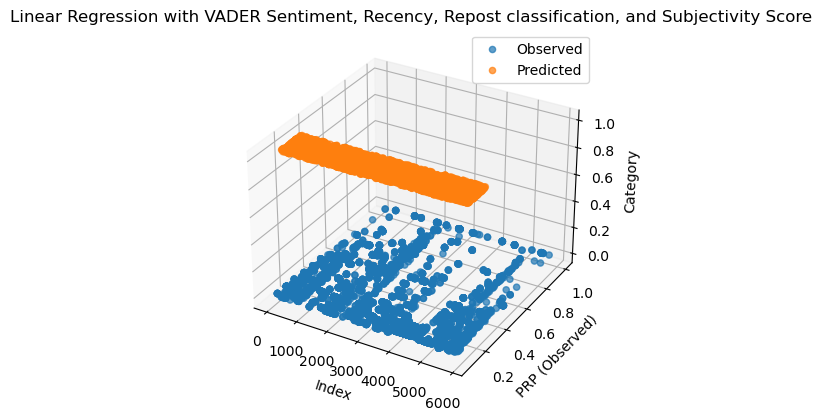

In [50]:
# Measuring performance
mse = mean_squared_error(lin_reg_4_y, y_pred)
r2 = r2_score(lin_reg_4_y, y_pred)
mae - mean_absolute_error(lin_reg_4_y, y_pred)

indices = range(len(lin_reg_4_y))  # Common index range for data points

# Create 3D plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Scatter plot for Observed and Predicted
ax.scatter(indices, lin_reg_4_y, zs=0, zdir='z', label="Observed", alpha=0.7)
ax.scatter(indices, y_pred, zs=1, zdir='z', label="Predicted", alpha=0.7)

# Customize plot
ax.set_title("Linear Regression with VADER Sentiment, Recency, Repost classification, and Subjectivity Score")
ax.set_xlabel("Index")
ax.set_ylabel("PRP (Observed)")
ax.set_zlabel("Category")  # Distinguishing observed vs predicted
ax.legend()

plt.show()

model_accuracies['4_linear_reg'] = {
    'mean_squared_error': mse,
    'r2_score': r2,
    'mean_absolute_error': mae
}

### Model Results

Using the transformed dataset to predict Player Relative Performance led to several findings:
- The model is fitting slightly better with the transformed dataset and more features
    - There is 1/4 as much data, so it's good that the model isn't underfitting as much
    - Still isn't capturing the outliers and better Player Relative Performances

## Logistic Regression

### Creating and training model

In [51]:
transformed_player_stat_tweet_df['Performance_Cat'] = pd.cut(transformed_player_stat_tweet_df['Player_Relative_Performance'], 
                               bins=[0,0.25,0.5,0.75,1], 
                               labels=[0,1,2,3],
                               include_lowest=True)

# Convert player name to categorical
transformed_player_stat_tweet_df['Player_Name'] = transformed_player_stat_tweet_df['Player_Name'].astype('category')
transformed_player_stat_tweet_df['Player_Name_cat'] = transformed_player_stat_tweet_df['Player_Name'].cat.codes

# Convert date to a categorical feature (assuming each date corresponds to a particular match)
transformed_player_stat_tweet_df['Date'] = transformed_player_stat_tweet_df['Date'].astype('category')
transformed_player_stat_tweet_df['Date_cat'] = transformed_player_stat_tweet_df['Date'].cat.codes

# is_repost is boolean; convert to int
transformed_player_stat_tweet_df['is_repost'] = transformed_player_stat_tweet_df['is_repost'].astype(int)

# Create day-of-week grouping for Days_Before_Game using modulo 7
transformed_player_stat_tweet_df['Day_Of_Week_Group'] = (transformed_player_stat_tweet_df['Days_Before_Game'] % 7).astype(int)

# This is arbitrary, adjust as needed.
transformed_player_stat_tweet_df['compound_bin'] = pd.cut(transformed_player_stat_tweet_df['compound_polarity_avg'], bins=[-1, 0.2, 0.5, 1], labels=[0, 1, 2])

# Bin subjectivity into ranges (for example, low, medium, high)
transformed_player_stat_tweet_df['subjectivity_bin'] = pd.cut(transformed_player_stat_tweet_df['subjectivity'], bins=[0, 0.33, 0.66, 1], labels=[0, 1, 2])

# For demonstration: Using the requested features - player name, is_repost, and date
# plus the binned features
features = ['Player_Name_cat', 'is_repost', 'Date_cat', 'compound_bin', 'subjectivity_bin', 'Day_Of_Week_Group']

# Convert categorical bins to codes
transformed_player_stat_tweet_df['compound_bin'] = transformed_player_stat_tweet_df['compound_bin'].astype(int)
transformed_player_stat_tweet_df['subjectivity_bin'] = transformed_player_stat_tweet_df['subjectivity_bin'].astype(int)

log_reg_X = transformed_player_stat_tweet_df[features]
log_reg_y = transformed_player_stat_tweet_df['Performance_Cat']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(log_reg_X, log_reg_y, test_size=0.3, random_state=42)

# Model training
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

### Visualizing and measuring performance

Accuracy: 0.3466135458167331
Confusion Matrix:
[[414 117 267 231]
 [116  56 158  87]
 [ 30  17 101  46]
 [ 26  15  38  38]]
Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.40      0.51      1029
           1       0.27      0.13      0.18       417
           2       0.18      0.52      0.27       194
           3       0.09      0.32      0.15       117

    accuracy                           0.35      1757
   macro avg       0.31      0.35      0.28      1757
weighted avg       0.50      0.35      0.38      1757



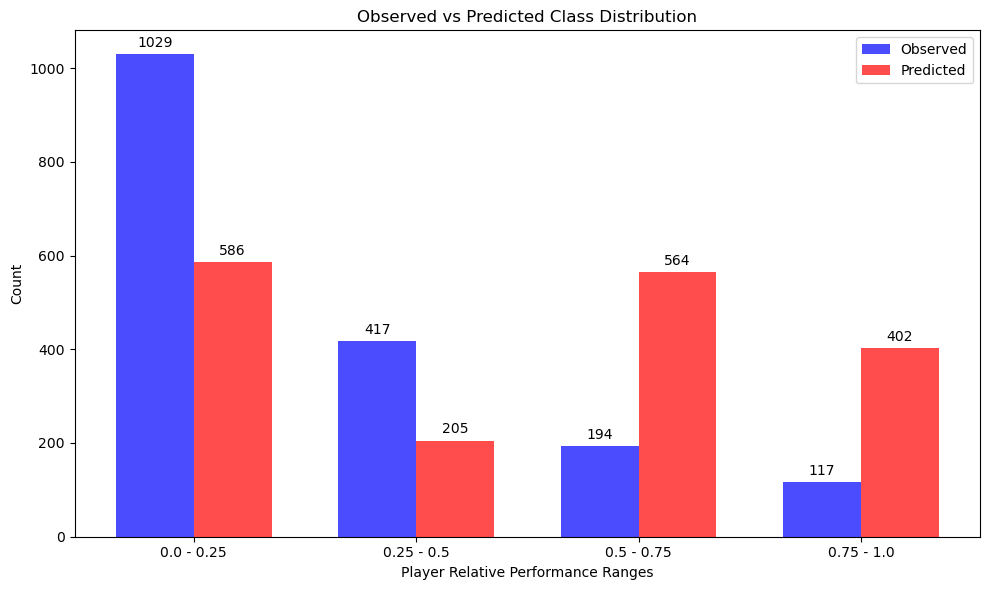

In [52]:
# Performance metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

mae = mean_absolute_error(y_test, y_pred)
ll = log_loss(y_test, y_pred_proba)

# Get the unique classes and sort them to ensure consistent order
classes = np.unique(np.concatenate((y_test, y_pred)))

# Count frequencies
observed_counts = [(y_test == c).sum() for c in classes]
predicted_counts = [(y_pred == c).sum() for c in classes]

# Define positions for the bars
x = np.arange(len(classes))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, observed_counts, width, label='Observed', alpha=0.7, color='blue')
rects2 = ax.bar(x + width/2, predicted_counts, width, label='Predicted', alpha=0.7, color='red')

# Add labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Count')
ax.set_title('Observed vs Predicted Class Distribution')
ax.set_xticks(x)
ax.set_xticklabels(['0.0 - 0.25', '0.25 - 0.5', '0.5 - 0.75', '0.75 - 1.0'])
ax.set_xlabel('Player Relative Performance Ranges')
ax.legend()

# Optional: Add counts above the bars
def autolabel(rects):
    """Attach a text label above each bar displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{}'.format(height),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # offset text placement 3 points above bar
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

model_accuracies['logistic_reg'] = {
    'mean_squared_error': mae,
    'log_loss': ll,
}

## Cross-validation techniques

### 2 Attribute Linear Regression train test split

In [53]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(lin_reg_2_X, lin_reg_2_y, test_size=0.3, random_state=42)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model on the training set
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Predictions on the test set
y_pred = model.predict(X_test_scaled)

# Performance metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

model_accuracies['2_linear_reg_train_test_split'] = {
    'mean_squared_error': mse,
    'r2_score': r2,
    'mean_absolute_error': mae
}

### 2 Attribute Linear Regression cross-validation

In [54]:
# Scale data once (important to do proper scaling inside CV pipeline ideally)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(lin_reg_2_X)

model = LinearRegression()

# Define K-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validation for MSE (negative MSE is returned by cross_val_score)
mse_scores = cross_val_score(model, X_scaled, lin_reg_2_y, cv=kf, scoring='neg_mean_squared_error')
r2_scores = cross_val_score(model, X_scaled, lin_reg_2_y, cv=kf, scoring='r2')
mae_scores = cross_val_score(model, X_scaled, lin_reg_2_y, cv=kf, scoring='neg_mean_absolute_error')

model_accuracies['2_linear_reg_cv'] = {
    'mean_squared_error': -np.mean(mse_scores),  # negate back
    'r2_score': np.mean(r2_scores),
    'mean_absolute_error': -np.mean(mae_scores)
}

### 4 Attribute Linear Regression train test split

In [55]:
X_train, X_test, y_train, y_test = train_test_split(lin_reg_4_X, lin_reg_4_y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

model_accuracies['4_linear_reg_train_test_split'] = {
    'mean_squared_error': mse,
    'r2_score': r2,
    'mean_absolute_error': mae
}

### 4 Attribute Linear Regression cross-validation

In [56]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(lin_reg_4_X)

model = LinearRegression()

kf = KFold(n_splits=5, shuffle=True, random_state=42)

mse_scores = cross_val_score(model, X_scaled, lin_reg_4_y, cv=kf, scoring='neg_mean_squared_error')
r2_scores = cross_val_score(model, X_scaled, lin_reg_4_y, cv=kf, scoring='r2')
mae_scores = cross_val_score(model, X_scaled, lin_reg_4_y, cv=kf, scoring='neg_mean_absolute_error')

model_accuracies['4_linear_reg_cv'] = {
    'mean_squared_error': -np.mean(mse_scores),
    'r2_score': np.mean(r2_scores),
    'mean_absolute_error': -np.mean(mae_scores)
}


### Logistic Regression with Categorized Performance

In [57]:
X_train, X_test, y_train, y_test = train_test_split(log_reg_X, log_reg_y, test_size=0.3, random_state=42)

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred)
ll = log_loss(y_test, y_pred_proba)
mae = mean_absolute_error(y_test, y_pred)

model_accuracies['logistic_reg_train_test_split'] = {
    'accuracy': acc,
    'log_loss': ll,
    'mean_absolute_error': mae
}

### Logistic Regression cross-validation

In [58]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define scorers
accuracy_scorer = make_scorer(accuracy_score)
neg_log_loss_scorer = make_scorer(log_loss, greater_is_better=False, needs_proba=True)
mae_scorer = make_scorer(mean_absolute_error)

# For logistic regression, cross_val_score directly:
acc_scores = cross_val_score(model, log_reg_X, log_reg_y, cv=skf, scoring=accuracy_scorer)

ll_scores = cross_val_score(model, log_reg_X, log_reg_y, cv=skf, scoring=neg_log_loss_scorer)
mae_scores = cross_val_score(model, log_reg_X, log_reg_y, cv=skf, scoring=mae_scorer)

model_accuracies['logistic_reg_cv'] = {
    'accuracy': np.mean(acc_scores),
    'log_loss': -np.mean(ll_scores),   # log_loss was negative
    'mean_absolute_error': np.mean(mae_scores)
}

### Cross-validation comparisons

In [59]:
# Convert model_accuracies to a DataFrame
comparison_df = pd.DataFrame(model_accuracies).T

# Print the DataFrame
print(comparison_df)

                               mean_squared_error  r2_score  \
2_linear_reg                             0.052554 -0.009883   
4_linear_reg                             0.063411 -0.122888   
logistic_reg                             1.173022       NaN   
2_linear_reg_train_test_split            0.052703  0.000747   
2_linear_reg_cv                          0.052001  0.000390   
4_linear_reg_train_test_split            0.056949 -0.001417   
4_linear_reg_cv                          0.056429 -0.000074   
logistic_reg_train_test_split                 NaN       NaN   
logistic_reg_cv                               NaN       NaN   

                               mean_absolute_error  log_loss  accuracy  
2_linear_reg                              0.169099       NaN       NaN  
4_linear_reg                              0.169099       NaN       NaN  
logistic_reg                                   NaN  1.374031       NaN  
2_linear_reg_train_test_split             0.174481       NaN       NaN  
2_li

#### Explanation

Between the linear models (2 and 4 attributes): The 2-feature linear model generally has a lower MSE than the 4-feature model, which indicates it may be performing slightly better at predicting but because of previously shown visualizations, the 2 feature model is actually performing worse because it has a larger dataset with more consistent data that is easier to predict. 

For the linear models, train-test split and CV give very similar MSE, R2, and MAE, indicating stable performance estimates.

For the logistic model, cross-validation yields slightly better results, suggesting that the single train-test split wasn’t fully representative and that multiple folds gave a more accurate picture.

In summary, these results indicate that the linear regression models are not performing well (as evidenced by negative R2 values). The logistic regression model’s performance metrics are slightly better under cross-validation than a single train-test split, implying that cross-validation provides a more reliable performance estimate.

## Bootstrap method

In [60]:
features = ['Player_Name_cat', 'is_repost', 'Date_cat', 'compound_bin', 'subjectivity_bin', 'Day_Of_Week_Group']

bootstrap_X = transformed_player_stat_tweet_df[features].values
bootstrap_y = transformed_player_stat_tweet_df['Performance_Cat'].values

# Number of bootstrap iterations
n_bootstrap = 1000

# List to store accuracy for each bootstrap iteration
accuracy_scores = []

# Standard scaler for feature scaling
scaler = StandardScaler()

for i in range(n_bootstrap):
    # Generate bootstrap indices
    bootstrap_indices = np.random.choice(len(bootstrap_X), size=len(bootstrap_X), replace=True)
    # Out-of-bag (OOB) indices are those not in bootstrap_indices
    oob_mask = np.ones(len(bootstrap_X), dtype=bool)
    oob_mask[bootstrap_indices] = False
    
    # If there are no OOB samples, skip this iteration
    if np.sum(oob_mask) == 0:
        continue
    
    X_train_boot = bootstrap_X[bootstrap_indices]
    y_train_boot = bootstrap_y[bootstrap_indices]
    X_oob = bootstrap_X[oob_mask]
    y_oob = bootstrap_y[oob_mask]

    # Scale data
    X_train_boot_scaled = scaler.fit_transform(X_train_boot)
    X_oob_scaled = scaler.transform(X_oob)

    # Fit model
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train_boot_scaled, y_train_boot)

    # Predict on OOB samples
    y_oob_pred = model.predict(X_oob_scaled)

    # Compute accuracy on OOB samples
    acc = accuracy_score(y_oob, y_oob_pred)
    accuracy_scores.append(acc)

# Compute mean and standard deviation of the accuracy across all bootstrap iterations
accuracy_mean = np.mean(accuracy_scores)
accuracy_std = np.std(accuracy_scores)

print(f"Bootstrap Accuracy Mean: {accuracy_mean}")
print(f"Bootstrap Accuracy Std: {accuracy_std}")

Bootstrap Accuracy Mean: 0.5722714780540837
Bootstrap Accuracy Std: 0.00863003821079146


#### Explanation

**Bootstrap Accuracy Mean: 0.572**

This indicates that, on average, the logistic regression model achieves an accuracy of about 57.2% when evaluated on out-of-bag samples. This is a measure of how well the model generalizes to unseen data, based on the bootstrapped samples.

**Bootstrap Accuracy Std: 0.0084**

The standard deviation of approximately 0.0084 (or 0.84%) indicates that the accuracy is fairly consistent across the bootstrap samples. A low standard deviation suggests that the model's performance is stable and does not vary much depending on the specific data points used for training.

## One-standard-error and Adjusted-R-squared comparison

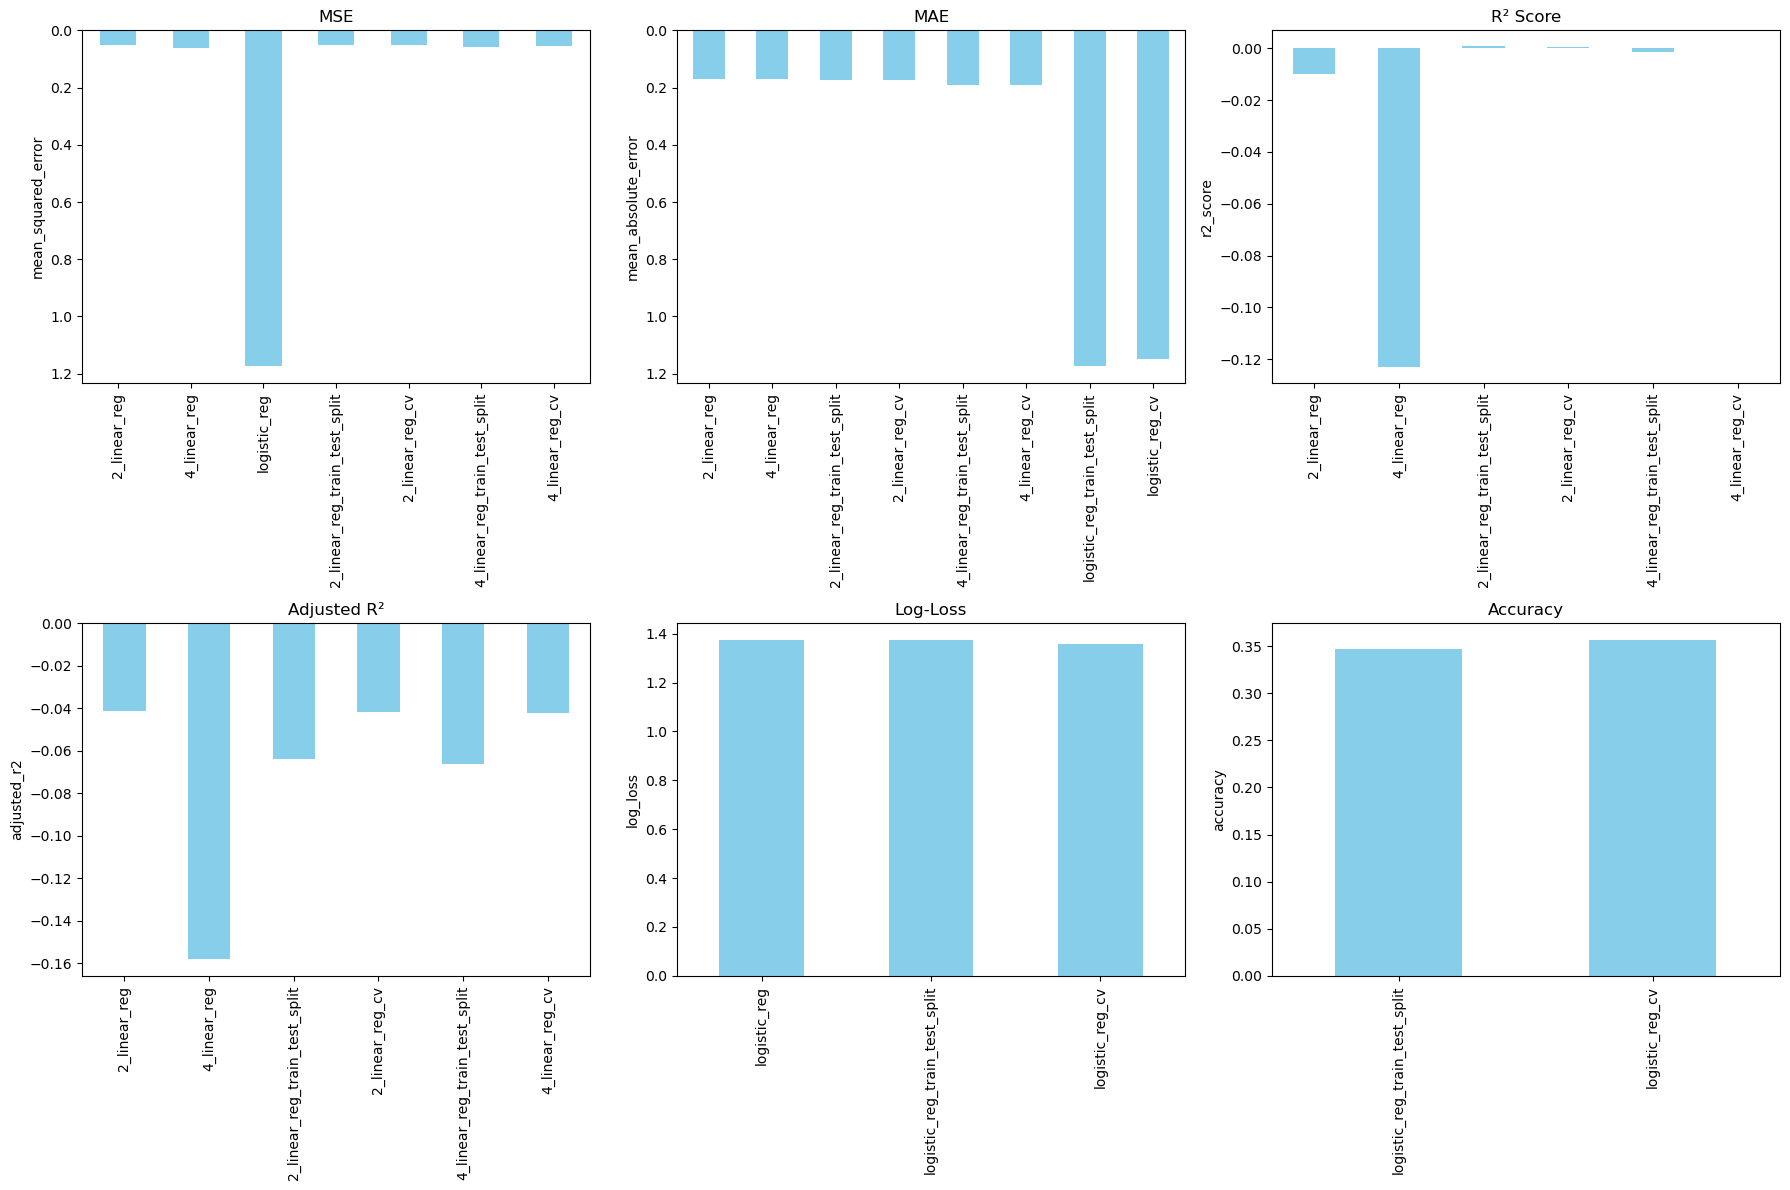

In [61]:
# Sample size approximation for the adjustments
n = 100

# Adjusted R-squared Calculation for linear models
comparison_df['adjusted_r2'] = comparison_df.apply(
    lambda row: 1 - (1 - row['r2_score']) * ((n - 1) / (n - row.name.count('_') - 2)) if 'linear' in row.name and not np.isnan(row['r2_score']) else np.nan, axis=1
)

# Setting up the figure and axes
fig, ax = plt.subplots(2, 3, figsize=(18, 12))  # Adjust figsize as needed

# Bar plots for each metric
metrics = ['mean_squared_error', 'mean_absolute_error', 'r2_score', 'adjusted_r2', 'log_loss', 'accuracy']
titles = ['MSE', 'MAE', 'R² Score', 'Adjusted R²', 'Log-Loss', 'Accuracy']

for i, metric in enumerate(metrics):
    axi = ax[i//3, i%3]
    comparison_df[metric].dropna().plot(kind='bar', ax=axi, color='skyblue', title=titles[i])
    axi.set_ylabel(metric)
    if 'error' in metric:  # Invert the axis for error metrics for better visual comparison
        axi.invert_yaxis()

plt.tight_layout()
plt.show()

#### Explanation

The most significant change by applying test-train splits and cross-validation to model preparation was the 4 Attribute Linear Regression. The R2 and adjusted-R2 scores decreased to a more acceptable value. Logistic regression on the other hand was relatively unaffected. 

## Conclusion

While using train-test splits and cross-validation was good for compounding our results, our findings have remained largely the same.

While logistic regression clearly seems to be the better model so far, it's still not fit for accurate predictions. Linear regression remains as a very poor choice, and based on these findings, a naive baseline model would perform better (although both linear regression models are glorified naive baselines).

Overall, neither of these models was sufficient for the task and a more complex model will certainly be needed.

# Supervised Learning

## Creating and training SVM model

In [70]:
# Features and target
X = player_stat_tweet_df.drop(columns=['Player_Relative_Performance'])  # Replace with all features you want to use
y = player_stat_tweet_df['Player_Relative_Performance']

# Handle datetime columns
if any(X.dtypes == 'datetime64[ns]'):
    for col in X.select_dtypes(include=['datetime64[ns]']):
        # Convert to numerical features like year, month, etc., or drop if not useful
        X[col + '_year'] = X[col].dt.year
        X[col + '_month'] = X[col].dt.month
        X[col + '_day'] = X[col].dt.day
    X = X.drop(columns=X.select_dtypes(include=['datetime64[ns]']).columns)

# Ensure all features are numerical and handle missing values
X = pd.get_dummies(X, drop_first=True)  # Convert categorical to numerical if necessary
X = X.fillna(0)  # Handle missing values

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Train the SVR model
svr_model = SVR(kernel='rbf')
svr_model.fit(X_train, y_train)

SVR()

## Visualizing and measuring performance

Mean Squared Error: 0.009896804697450941
R2 Score: 0.8044941890226006


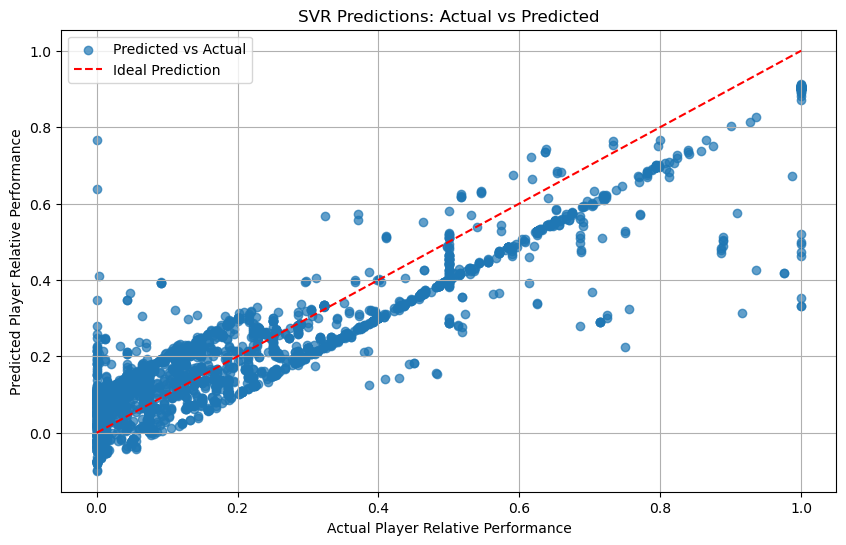

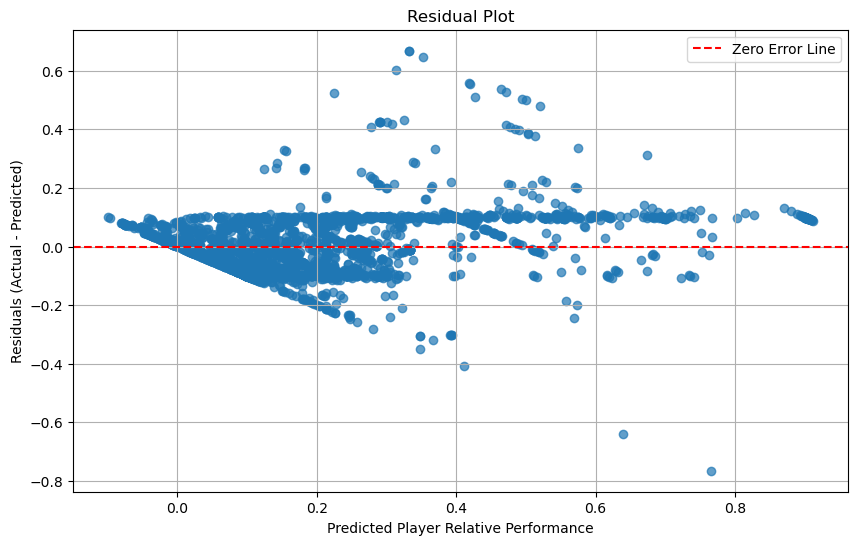

In [71]:
# Make predictions
y_pred = svr_model.predict(X_test)

# Evaluate the model
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

# Scatter plot to visualize actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7, label="Predicted vs Actual")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label="Ideal Prediction")
plt.title("SVR Predictions: Actual vs Predicted")
plt.xlabel("Actual Player Relative Performance")
plt.ylabel("Predicted Player Relative Performance")
plt.legend()
plt.grid(True)
plt.show()

# Residual plot to check prediction errors
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--', label="Zero Error Line")
plt.title("Residual Plot")
plt.xlabel("Predicted Player Relative Performance")
plt.ylabel("Residuals (Actual - Predicted)")
plt.legend()
plt.grid(True)
plt.show()

#### Explanation

**R-squared (0.80):**

- Indicates that the model explains 80% of the variance in the target variable (Player Relative Performance). This is a strong result, suggesting that the model captures most of the underlying patterns in the data.

**Mean Absolute Error (MAE - 0.08):**

- On average, the predictions are off by 0.08 units. Considering the scale of Player Relative Performance, this represents relatively low prediction error, indicating good accuracy.

**Mean Squared Error (MSE - 0.01):**

- The squared error (penalizing larger errors more heavily) is also very low, further reinforcing the conclusion that the model's predictions are accurate.

**Correlation (0.91):**

- A strong positive correlation between actual and predicted values demonstrates that the model's predictions align closely with the actual performance values.

**Residual Mean (-0.02):**

- The residuals have a mean close to zero, which is desirable. It suggests that the model's predictions are not systematically biased (i.e., not consistently overestimating or underestimating).

**Residual Standard Deviation (0.10):**

- Residuals have low variability, indicating that the errors are not widely spread. This points to consistency in the model's predictions.

# Unsupervised Learning

## Creating and training K-means clustering model

In [72]:
# Select features for clustering
features = ['compound', 'polarity', 'subjectivity', 'Days_Before_Game']
X = player_stat_tweet_df[features]

# Normalize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Determine the optimal number of clusters using the Elbow Method
inertia = []
k_values = range(1, 11)
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

## Visualizing and measuring performance

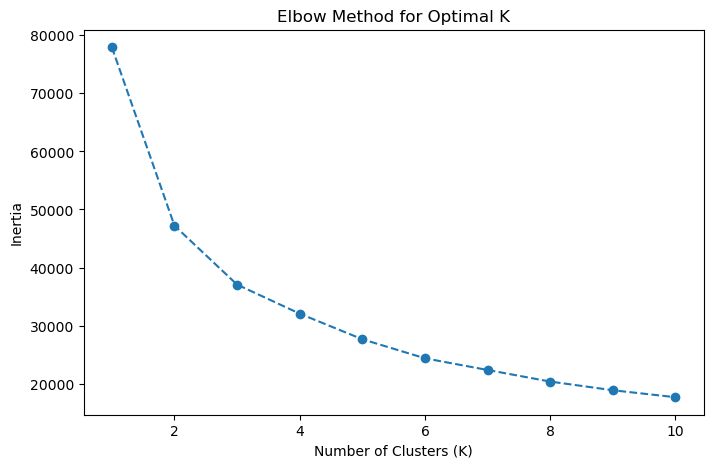

Silhouette Score: 0.39


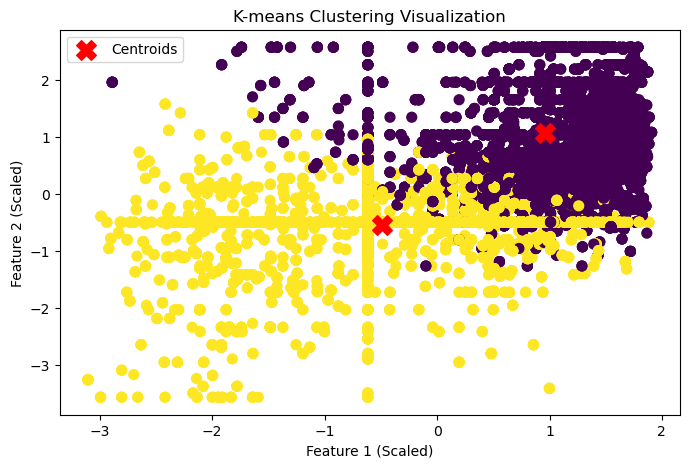

In [73]:
# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.show()

# Choose the optimal K (e.g., based on the elbow plot)
optimal_k = 2  # Adjust based on the elbow plot

# Apply K-means with the optimal number of clusters
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
kmeans.fit(X_scaled)

# Add cluster labels to the dataset
player_stat_tweet_df['Cluster'] = kmeans.labels_

# Evaluate the clustering using silhouette score
silhouette_avg = silhouette_score(X_scaled, kmeans.labels_)
print(f'Silhouette Score: {silhouette_avg:.2f}')

# Visualize the clusters (using the first two features for simplicity)
plt.figure(figsize=(8, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans.labels_, cmap='viridis', s=50)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', marker='X', s=200, label='Centroids')
plt.xlabel('Feature 1 (Scaled)')
plt.ylabel('Feature 2 (Scaled)')
plt.title('K-means Clustering Visualization')
plt.legend()
plt.show()

### Explanation

**Cluster 0:**

- Higher compound score (0.617), indicating a generally positive sentiment in the tweets.
- Positive polarity (0.507), suggesting the language in the tweets tends to be more optimistic or agreeable.
- Higher subjectivity (0.622), reflecting a more personal or opinionated tone in the content.
- Slightly closer to the game day on average (Days_Before_Game: 14.97).
- Interpretation: This cluster likely represents tweets that are more emotionally charged and positive, possibly expressing excitement or support for the player or team in the lead-up to the game. The higher subjectivity suggests these posts might include personal opinions, cheers, or fan commentary.

**Cluster 1:**

- Lower compound score (0.049), indicating a neutral to slightly negative sentiment.
- Slightly negative polarity (-0.016), suggesting a more critical or indifferent tone.
- Lower subjectivity (0.123), indicating a factual or objective tone in the tweets.
- Slightly farther from the game day on average (Days_Before_Game: 15.10).
- Interpretation: This cluster likely represents tweets that are more neutral or even critical, with less emotional involvement. The lower subjectivity suggests these might be factual updates, news, or impersonal comments.

## Conclusion

For both modelling techniques, we switched back to the original dataset instead of the filtered one. This is because the models performed significantly better on the original dataset, as both the SVR and K-means clustering benefited from the extra data and didn't normalize and simplify predictions like the regression models did.

As expected, the SVR had an accuracy score of 80%, which means it would be a good predictor of player performance. This was forseen, as it makes sense that more complex models would be able to handle the deep relationships within the data.

Additionally, the clustering with K-Means revealed that a good way to group the features was with 2 different kinds of tweets related to player performance: a positive, more chronologically close tweet, and a more neutral, objective tweet that is chronologically further from the game. This is a logical distinction and it will be interesting to see how including this cluster classification as a feature will affect future models.

# Decision Trees

In [ ]:
# Feature engineering: "day of the week"
transformed_player_stat_tweet_df['Date'] = pd.to_datetime(transformed_player_stat_tweet_df['Date'])
transformed_player_stat_tweet_df['Day_of_Week'] = transformed_player_stat_tweet_df['Date'].dt.dayofweek  # Monday=0, Sunday=6

# Prepare features and target
features = ['neg', 'neu', 'pos', 'compound', 'polarity', 'subjectivity', 'Days_Before_Game', 'is_repost', 'Day_of_Week']
X = transformed_player_stat_tweet_df[features]
y = transformed_player_stat_tweet_df['Player_Relative_Performance']

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Regression Tree
reg_tree = DecisionTreeRegressor(max_depth=5, random_state=42)
reg_tree.fit(X_train, y_train)
y_pred_reg = reg_tree.predict(X_test)

# Evaluate Regression Tree
mae = mean_absolute_error(y_test, y_pred_reg)
r2 = r2_score(y_test, y_pred_reg)
print(f"Regression Tree MAE: {mae}")
print(f"Regression Tree R²: {r2}")

Regression Tree MAE: 0.1873265500500879
Regression Tree R²: 0.017415230718654362


#### Explanation

It seems that the reggression tree is not effectively understanding the complexity of the data. This might be due to the nonlinear relationships between features.

# Conclusion

## Lessons Learned

Due to the success of the Support Vector Regression model, it is safe to say that NFL Player Performance can be accurately predicted using only the tweets that an NFL player posts. However, it's important to note that outliers (especially very good performances) will be hard to predict and will go overlooked most of the time.

Across all of the models, it's apparent that the prediction was certainly complex and not easy to handle, which is why most of the models performed extremely poorly.

Overall, serious strides were made towards the original goal of understanding the relationship between player tweets (mental state) and performance.

## Future Work

This project has several avenues to continue exploring the relationship between the mental state of NFL players and their performances:
- Extracting more data
    - The project was severely limited by the amount of data available
        - The player-handle map only included around 200 connections, but there are certainly hundreds (if not thousands) more NFL players that use twitter
    - Other social media platforms could be scraped, like Facebook, Instagram, Snapchat, etc.
    - Statistics like a boolean column that represents if a player started, whether a player was injured, or how many years they were in the NFL could lead to a more accurate Player Relative Performance
    - Enhanced text sentiment analysis with LLM's or more complex/specific models
    - Eliminate any discrepancies in the data that might disrupt or distract from the relationship between tweets and player performance
        - Disassociate tweets that react to performances as opposed to the other way around
- Stemming to other potentially predictive metrics to better gauge Player Relative Performance
    - Other statistics
        - Create lag statistical features
    - Weather data
    - Injury reports
    - Performance of related positions (e.g. QB performance might be heavily influenced by performance of offensive linemen or wide receivers)
    - Fantasy statistcs
    - Coaching strategies and play-calling tendencies
- Use gathered data to try to understand the relationship between mental state and performance
    - Could be used to make recommendations to prospective athletes
    - Understand the psychology around the pressure and circumstances of professional football games
- Create a live dashboard that predicts player performances for upcoming games
- Work with NFL players to understand how they use social media